In [1]:
from prophet.serialize import model_from_json
from prophet import Prophet

/home/henrique/miniconda3/envs/tf/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
with open("model.json", "r") as fin:
    m = model_from_json(fin.read())  # Load model

/home/henrique/miniconda3/envs/tf/lib/python3.9/site-packages/prophet/serialize.py:160: FutureWarning: The behavior of Timestamp.utcfromtimestamp is deprecated, in a future version will return a timezone-aware Timestamp with UTC timezone. To keep the old behavior, use Timestamp.utcfromtimestamp(ts).tz_localize(None). To get the future behavior, use Timestamp.fromtimestamp(ts, 'UTC')
  setattr(model, attribute, pd.Timestamp.utcfromtimestamp(model_dict[attribute]).tz_localize(None))


In [3]:
future = m.make_future_dataframe(periods=12, freq="MS")

forecast = m.predict(future)

In [4]:
forecast[['ds','yhat']].tail(12)

,ds,yhat
90,2026-12-01,7959.077371
91,2027-01-01,5882.133073
92,2027-02-01,7559.772164
93,2027-03-01,7160.536678
94,2027-04-01,6520.939753
95,2027-05-01,6840.499086
96,2027-06-01,7300.101405
97,2027-07-01,6720.218107
98,2027-08-01,6880.323504
99,2027-09-01,7340.290217


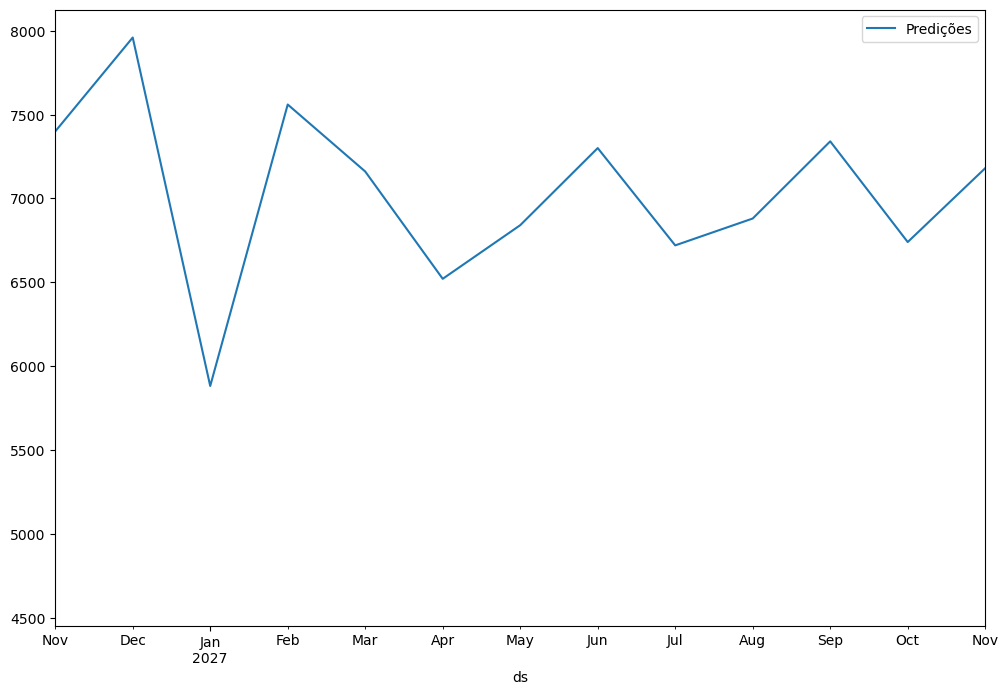

In [5]:
ax = forecast.plot(x="ds", y="yhat", label="Predições", legend=True, figsize=(12, 8),xlim=['2026-11-01', '2027-11-01'])

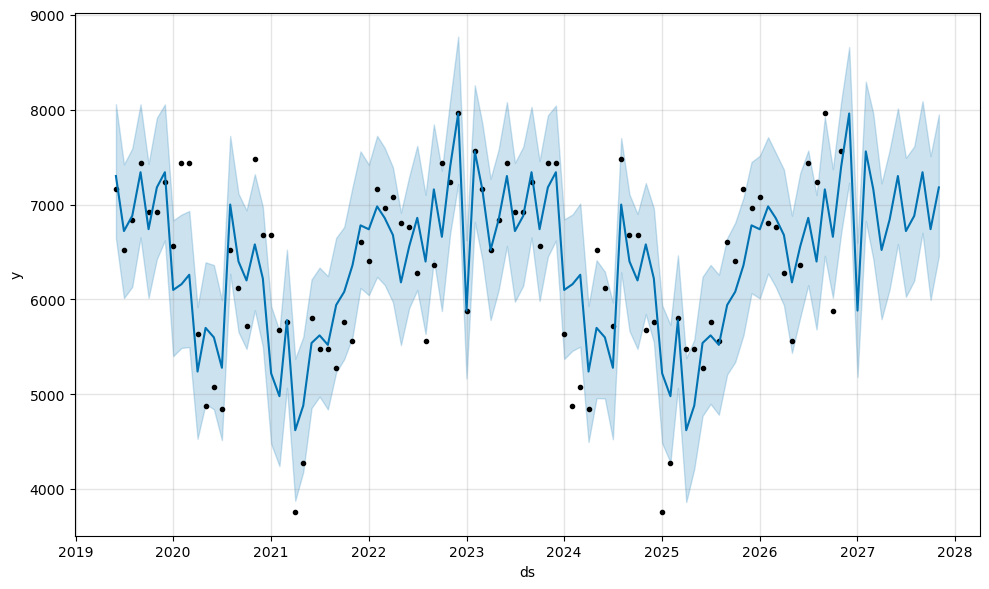

In [6]:
m.plot(forecast,uncertainty=True);